In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ta  
from datetime import datetime

In [35]:
# Loading the CSV file
file_path = 'STOCK_US_XNAS_AAPL.csv'
df = pd.read_csv(file_path)

In [9]:
print("Original Data:")
print(df.head())

Original Data:
         Date    Open    High     Low   Close      Volume
0  04/29/2025  208.69  212.24  208.37  211.21  36,827,633
1  04/28/2025  210.00  211.50  207.46  210.14  38,743,070
2  04/25/2025  206.37  209.75  206.20  209.28  38,222,262
3  04/24/2025  204.89  208.83  202.94  208.37  47,310,992
4  04/23/2025  206.00  208.00  202.80  204.60  52,929,168


In [10]:
# Convert 'Date' column to datetime and sort chronologically
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)

In [11]:
df.reset_index(drop=True, inplace=True)

In [12]:
# Rename columns to match expected format if necessary
df.rename(columns=lambda x: x.strip().capitalize(), inplace=True)

In [13]:
# Drop rows with missing values
df.dropna(inplace=True)

In [14]:
# Simple Moving Average (20 days)
df['SMA_20'] = ta.trend.sma_indicator(df['Close'], window=20)
# Exponential Moving Average (50 days)
df['EMA_50'] = ta.trend.ema_indicator(df['Close'], window=50)
# RSI (14 days)
df['RSI_14'] = ta.momentum.rsi(df['Close'], window=14)
# MACD and Signal
df['MACD'] = ta.trend.macd(df['Close'])
df['MACD_Signal'] = ta.trend.macd_signal(df['Close'])

In [15]:
# Daily Return
df['Daily_Return'] = df['Close'].pct_change()

In [16]:
df.dropna(inplace=True)

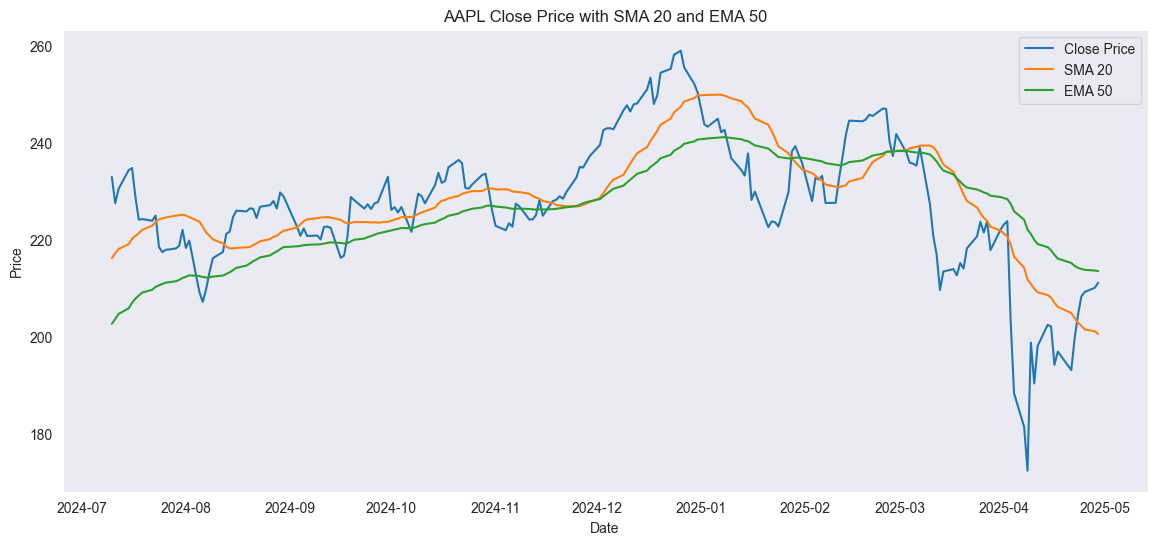

In [17]:
# 1. Close Price with SMA and EMA
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Close'], label='Close Price')
plt.plot(df['Date'], df['SMA_20'], label='SMA 20')
plt.plot(df['Date'], df['EMA_50'], label='EMA 50')
plt.title('AAPL Close Price with SMA 20 and EMA 50')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()

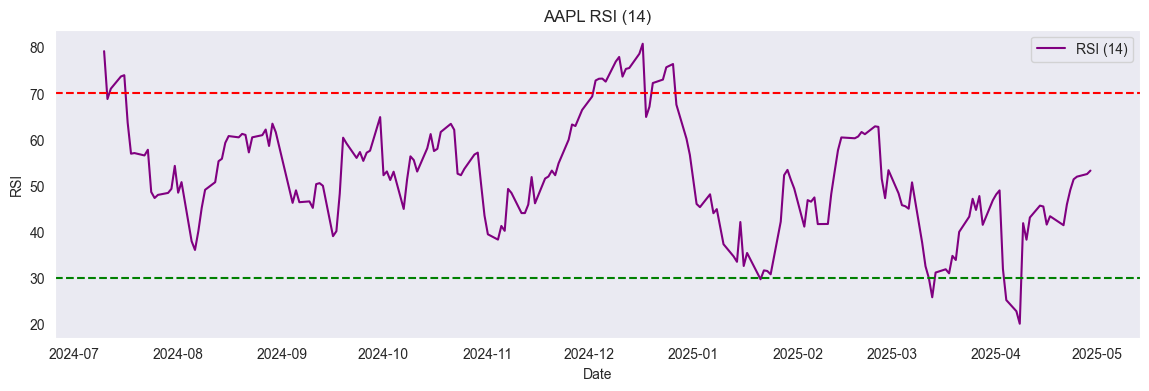

In [18]:
# 2. RSI
plt.figure(figsize=(14, 4))
plt.plot(df['Date'], df['RSI_14'], label='RSI (14)', color='purple')
plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')
plt.title('AAPL RSI (14)')
plt.xlabel('Date')
plt.ylabel('RSI')
plt.grid()
plt.legend()
plt.show()


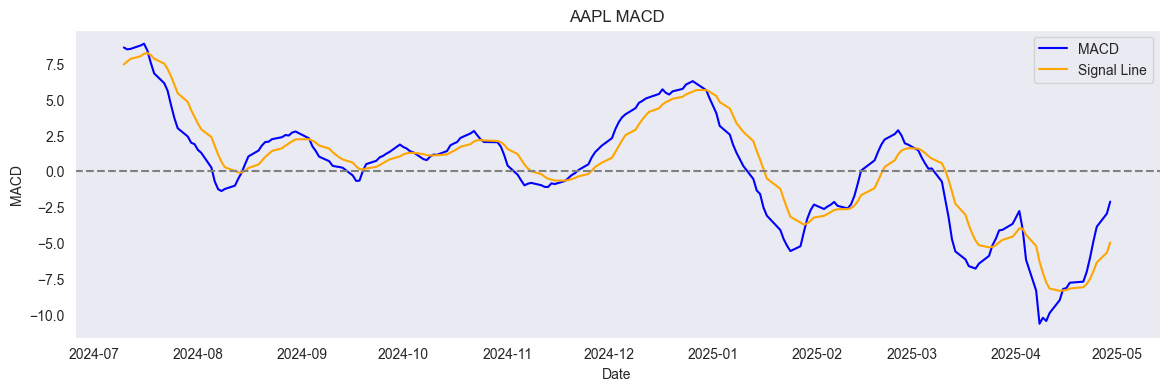

In [19]:
# 3. MACD
plt.figure(figsize=(14, 4))
plt.plot(df['Date'], df['MACD'], label='MACD', color='blue')
plt.plot(df['Date'], df['MACD_Signal'], label='Signal Line', color='orange')
plt.axhline(0, color='gray', linestyle='--')
plt.title('AAPL MACD')
plt.xlabel('Date')
plt.ylabel('MACD')
plt.legend()
plt.grid()
plt.show()


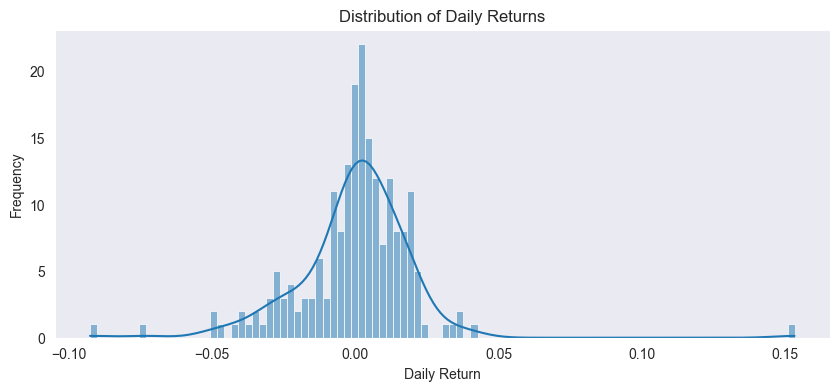

In [20]:
# 4. Distribution of Daily Returns
plt.figure(figsize=(10, 4))
sns.histplot(df['Daily_Return'], bins=100, kde=True)
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid()
plt.show()

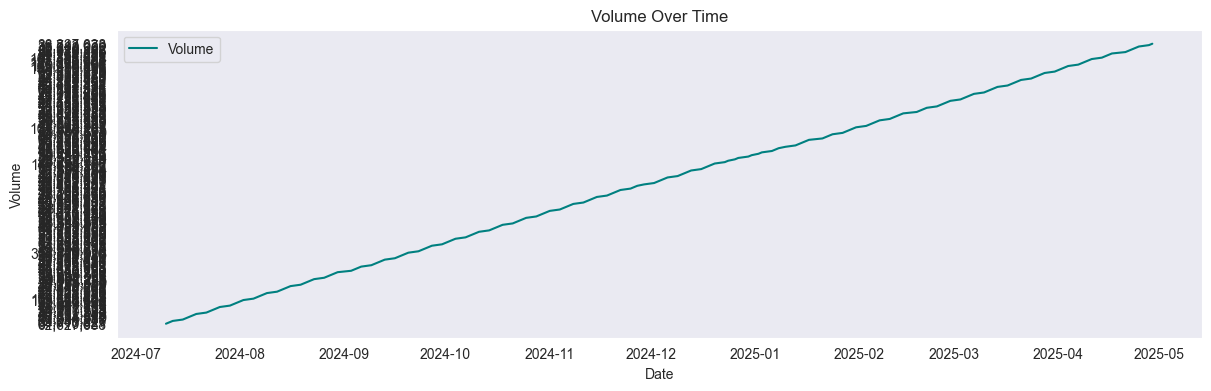

In [21]:
# 5. Volume Over Time
plt.figure(figsize=(14, 4))
plt.plot(df['Date'], df['Volume'], label='Volume', color='teal')
plt.title('Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid()
plt.legend()
plt.show()

In [22]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve

In [23]:
df=df.to_csv("processed_aapl_data.csv")

In [24]:
# Load processed DataFrame from Task 1
df = pd.read_csv("processed_aapl_data.csv",parse_dates=['Date'])

In [25]:
# Predict if Close price will go up the next day
df['Target'] = np.where(df['Close'].shift(-1) > df['Close'], 1,0)

In [26]:
# Drop the last row (has no future price to compare)
df = df[:-1]

In [27]:
features = ['SMA_20', 'EMA_50', 'RSI_14', 'MACD', 'MACD_Signal', 'Daily_Return']
X = df[features]
y = df['Target']

In [28]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, shuffle=False)

In [32]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

In [33]:
results = {}
# Confusion Matrix and ROC for each
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    results[name] = {
        "model": model,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "y_pred": y_pred,
        "y_prob": y_prob
    }


📌 Logistic Regression Evaluation:
Accuracy : 0.5122
Precision: 0.5122
Recall   : 1.0000
F1-Score : 0.6774
ROC-AUC  : 0.7167


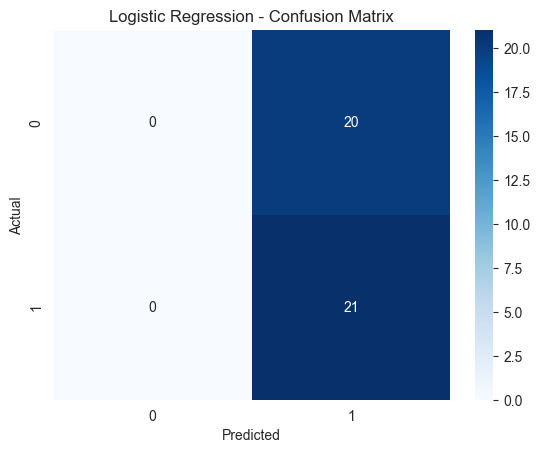


📌 Random Forest Evaluation:
Accuracy : 0.5854
Precision: 0.5556
Recall   : 0.9524
F1-Score : 0.7018
ROC-AUC  : 0.6524


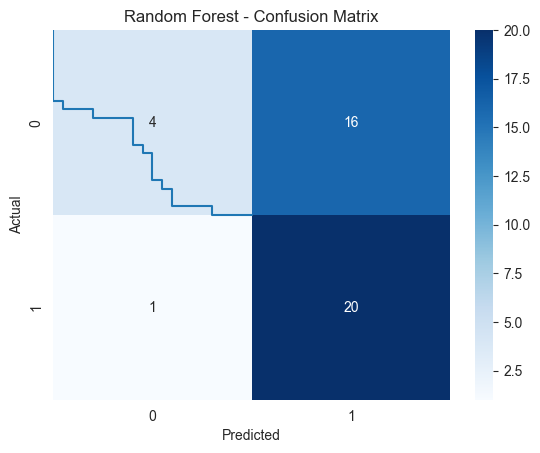


📌 XGBoost Evaluation:
Accuracy : 0.5610
Precision: 0.5405
Recall   : 0.9524
F1-Score : 0.6897
ROC-AUC  : 0.6500


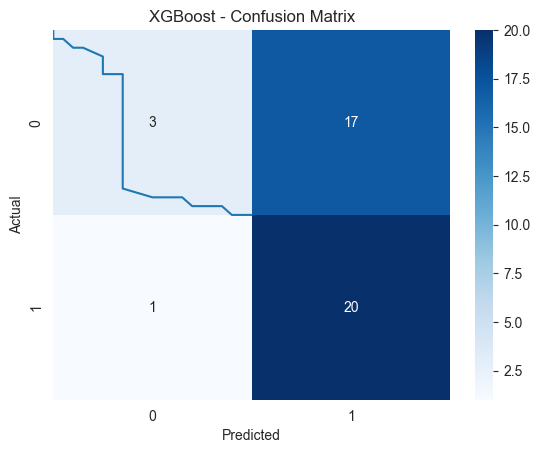

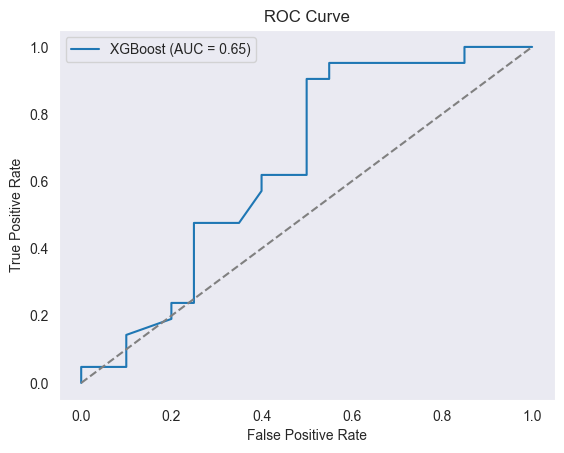

In [34]:
for name, res in results.items():
    print(f"\n📌 {name} Evaluation:")
    print(f"Accuracy : {res['accuracy']:.4f}")
    print(f"Precision: {res['precision']:.4f}")
    print(f"Recall   : {res['recall']:.4f}")
    print(f"F1-Score : {res['f1_score']:.4f}")
    print(f"ROC-AUC  : {res['roc_auc']:.4f}")
    
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['roc_auc']:.2f})")
    
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()